# Train and Evaluate

Trains a registered model on the full training corpus and reports point-forecast metrics (MAE, RMSE, MASE, sMAPE, R^2, directional accuracy), plus the train/val loss curve, in one notebook instead of spread across scripts.

Metrics are scored against real, QC-valid conductivity observations only, same convention as `scripts/forecast_skill_baseline.py`. Trains in memory by default -- flip `SAVE_CHECKPOINT` in the config cell to also overwrite `checkpoints/{model}_weights.pt` and `_metadata.pkl`, same schema `main.py --mode train` produces.

In [19]:
import os, sys
_here = os.getcwd()
if os.path.basename(_here) == "notebooks":
    os.chdir(os.path.dirname(_here))
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import inspect
import pickle

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from strawberrywatch import paths
from strawberrywatch.config import Config
from strawberrywatch.ingest.data_loader import load_and_preprocess_data
from strawberrywatch.utils.graph_utils import create_graph_topology
from strawberrywatch.preprocessing.data_processor import prepare_sequences_normalized
from strawberrywatch.training.trainer import train_temporal_gnn
from strawberrywatch.models.Dusk_Crayfish import DuskCrayfish

# Add new architectures here as they get wired in; nothing else below changes.
MODEL_REGISTRY = {
    "dusk_crayfish": DuskCrayfish,
}

## Config

In [20]:
MODEL_NAME = "dusk_crayfish"
SAVE_CHECKPOINT = False  # True overwrites checkpoints/{MODEL_NAME}_weights.pt and _metadata.pkl
MIN_EVALUABLE = 200  # per-node sample floor below which metrics are not trusted

CORPUS_PATH = paths.training_corpus()
LAG_15MIN = pd.Timedelta(minutes=15)

## Hyperparameter sweep configs

`epochs`, `batch_size`, and `learning_rate` are plain arguments to `train_temporal_gnn` (see its signature) -- no need to touch `Config` for these three, unlike architecture knobs (`hidden_dim`, `gnn_layers`, etc.) which `DuskCrayfish.__init__` reads off `Config` directly.

Each entry is the full baseline plus one override, not a sparse diff, so runs stay order-independent regardless of what ran before them in the loop.

- `more_epochs`: baseline's val loss barely moved epoch 1 -> 10 (0.403326 -> 0.403075) while train loss kept dropping -- that plateau could mean it's genuinely converged, or that it needs more room to move. 30 epochs (with the existing early-stopping patience) checks which.
- `lower_lr`: a val loss that goes flat immediately can also mean the step size is too coarse to make further progress. 3e-4 is a gentler, still-common Adam default to test against 1e-3.
- `smaller_batch`: 64 instead of 128 doubles the gradient updates per epoch on the same data, a cheap way to test if update frequency (not epoch count) is the bottleneck.

In [21]:
BASELINE = {
    "epochs": Config.EPOCHS,
    "batch_size": Config.BATCH_SIZE,
    "learning_rate": Config.LEARNING_RATE,
}

CONFIGS = [
    {"name": "baseline", **BASELINE},
    {"name": "more_epochs", **{**BASELINE, "epochs": 30}},
    {"name": "lower_lr", **{**BASELINE, "learning_rate": 0.0003}},
    {"name": "smaller_batch", **{**BASELINE, "batch_size": 64}},
]

for cfg in CONFIGS:
    print(cfg)

{'name': 'baseline', 'epochs': 10, 'batch_size': 128, 'learning_rate': 0.001}
{'name': 'more_epochs', 'epochs': 30, 'batch_size': 128, 'learning_rate': 0.001}
{'name': 'lower_lr', 'epochs': 10, 'batch_size': 128, 'learning_rate': 0.0003}
{'name': 'smaller_batch', 'epochs': 10, 'batch_size': 64, 'learning_rate': 0.001}


## Build the train/val split

Chronological split over the full corpus via `Config.TRAIN_SPLIT`, same as `main.py --mode train`.

In [22]:
edge_index, _, location_to_idx = create_graph_topology()
df_featured, _, _ = load_and_preprocess_data(file_path=CORPUS_PATH, force_download=True, days=999)
sequences, targets, timestamps, scaler, feature_cols, node_mask_seq, target_mask = (
    prepare_sequences_normalized(
        df_featured, location_to_idx, Config.SEQUENCE_LENGTH, return_node_mask=True
    )
)

split_idx = int(len(sequences) * Config.TRAIN_SPLIT)
train_seq, val_seq = sequences[:split_idx], sequences[split_idx:]
train_tgt, val_tgt = targets[:split_idx], targets[split_idx:]
train_node_mask, val_node_mask = node_mask_seq[:split_idx], node_mask_seq[split_idx:]
train_target_mask, val_target_mask = target_mask[:split_idx], target_mask[split_idx:]
val_ts = pd.DatetimeIndex(timestamps[split_idx:])
node_names = list(location_to_idx.keys())
num_nodes = len(node_names)
num_features = len(feature_cols)

print(f"train sequences: {len(train_seq):,}, val sequences: {len(val_seq):,}")
print(f"val range: {val_ts[0]} -> {val_ts[-1]}")

graph topology: 4 nodes, 3 edges, device=cpu

'/Users/1an/Desktop/Projects/School/StrawberryWatch/data/processed_data/training_corpus.csv' is a wide training corpus (has *_valid columns); loading directly, skipping fetch/merge.
wide corpus converted: 4 sites x 32,440 timesteps -> 129,760 long rows
data loaded:
Rows: 129,760
Range: 2025-06-04 03:30:00+00:00 to 2026-05-08 01:15:00+00:00
Sites present (4): ['north_fork_0', 'oxford', 'south_fork_1', 'south_fork_2']
Active features (10): conductivity, depth, temperature, rain_mm, air_temp_c, shortwave_radiation, hour_sin, hour_cos, dayofyear_sin, dayofyear_cos
---------------------------

using 10 features: conductivity, depth, temperature, rain_mm, air_temp_c, shortwave_radiation, hour_sin, hour_cos, dayofyear_sin, dayofyear_cos
imputing gaps up to 24h (96 rows)...
  [north_fork_0] filled 5268 missing values
  [oxford] filled 408 missing values
  [south_fork_1] filled 8784 missing values
  [south_fork_2] filled 2325 missing values
filled 1

Pivoting data: 100%|██████████| 32440/32440 [00:14<00:00, 2177.27it/s]


node_mask source: QC 'valid' column (training-corpus data)
transient absences: 23,164 cells (1.8% of all (t, node, feature) cells)

valid timesteps: 32,440 / 32,440
after node filter: 32,440 / 32,440 valid timesteps
creating sequences (length 24)...


Sliding window: 100%|██████████| 32416/32416 [00:00<00:00, 83422.54it/s]


done. 32,416 sequences total
train sequences: 25,932, val sequences: 6,484
val range: 2026-03-01 12:30:00+00:00 -> 2026-05-08 01:15:00+00:00


## Build and train the model

PyTorch doesn't have a Keras-style `model.fit()`/`History` object -- `train_temporal_gnn` already returns `train_losses`/`val_losses` as plain per-epoch lists, which *is* that history, just plotted manually below instead of via `history.history["loss"]`.

In [26]:
ModelClass = MODEL_REGISTRY[MODEL_NAME]
model_kwargs = {"num_node_features": num_features}
if "num_nodes" in inspect.signature(ModelClass.__init__).parameters:
    model_kwargs["num_nodes"] = num_nodes
model = ModelClass(**model_kwargs).to(Config.DEVICE)

train_losses, val_losses, threshold, node_error_stats = train_temporal_gnn(
    model,
    train_seq, train_tgt, edge_index,
    val_sequences=val_seq, val_targets=val_tgt,
    feature_cols=feature_cols,
    train_node_mask=train_node_mask, val_node_mask=val_node_mask,
    train_target_mask=train_target_mask, val_target_mask=val_target_mask,
)

loss scored on: ['conductivity', 'depth', 'temperature'] (indices [0, 1, 2]) -- everything else is input-only
training on CPU (fp32)...
Epoch   1/10 | Train Loss: 0.004316 | Val Loss: 0.403555
Epoch   5/10 | Train Loss: 0.002859 | Val Loss: 0.403117
Epoch  10/10 | Train Loss: 0.002786 | Val Loss: 0.403197
restored best weights (val loss 0.403087)
  node 3: excluding 460/6484 QC-invalid targets from threshold calibration
spill threshold: 0.571204 (P99, scored on conductivity only (feature index 0))
training done.



## Optionally save the checkpoint

Only runs if `SAVE_CHECKPOINT = True` in the config cell. Writes the same weights + metadata schema `main.py --mode train` produces, so `main.py` can load this checkpoint back.

In [ ]:
if SAVE_CHECKPOINT:
    checkpoints_dir = paths.checkpoints_dir()
    os.makedirs(checkpoints_dir, exist_ok=True)
    torch.save(model.state_dict(), checkpoints_dir / f"{MODEL_NAME}_weights.pt")

    idx_to_location = {idx: loc for loc, idx in location_to_idx.items()}
    if node_error_stats:
        error_median = {idx_to_location[i]: s["median"] for i, s in node_error_stats.items()}
        error_iqr = {idx_to_location[i]: s["iqr"] for i, s in node_error_stats.items()}
        node_thresholds = {idx_to_location[i]: s["threshold"] for i, s in node_error_stats.items()}
        cond_median = {idx_to_location[i]: s["cond_median"] for i, s in node_error_stats.items()}
        cond_iqr = {idx_to_location[i]: s["cond_iqr"] for i, s in node_error_stats.items()}
    else:
        error_median, error_iqr, node_thresholds = {}, {}, {}
        cond_median, cond_iqr = {}, {}

    with open(checkpoints_dir / f"{MODEL_NAME}_metadata.pkl", "wb") as f:
        pickle.dump({
            "scaler": scaler,
            "feature_cols": feature_cols,
            "location_to_idx": location_to_idx,
            "threshold": threshold,
            "threshold_percentile": Config.THRESHOLD_PERCENTILE,
            "error_median": error_median,
            "error_iqr": error_iqr,
            "node_thresholds": node_thresholds,
            "cond_median": cond_median,
            "cond_iqr": cond_iqr,
        }, f)
    print(f"checkpoint saved to {checkpoints_dir}")
else:
    print("SAVE_CHECKPOINT is False -- trained in memory only, checkpoints/ untouched")

## Run the trained model over the held-out split

In [27]:
def run_model_over(model, edge_index, seq, node_mask, num_nodes, batch_size=256):
    """Batched forward pass, node_mask passed only if the model's forward() accepts it."""
    supports_mask = "node_mask" in inspect.signature(model.forward).parameters
    preds = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(seq), batch_size):
            seq_t = torch.FloatTensor(seq[i:i + batch_size]).to(Config.DEVICE)
            kwargs = dict(batch_size=len(seq_t), num_nodes=num_nodes)
            if supports_mask:
                kwargs["node_mask"] = torch.BoolTensor(node_mask[i:i + batch_size]).to(Config.DEVICE)
            preds.append(model(seq_t, edge_index, **kwargs).cpu().numpy())
    return np.concatenate(preds, axis=0)


preds_norm = run_model_over(model, edge_index, val_seq, val_node_mask, num_nodes)
cond_idx = feature_cols.index("conductivity")
cond_mean, cond_scale = scaler.mean_[cond_idx], scaler.scale_[cond_idx]
preds_raw_cond = preds_norm[:, :, cond_idx] * cond_scale + cond_mean  # (n_val, num_nodes)
print(f"predictions shape: {preds_norm.shape}")

predictions shape: (6484, 4, 10)


## Metrics: MAE, RMSE, MASE, sMAPE, R^2, directional accuracy

Computed on real (non-imputed, QC-valid) conductivity read straight off the corpus, matched to a real 15-min lag so MASE's naive-persistence denominator is on real values too. All of these apply identically to a future ARIMA model (or anything else that outputs a point forecast), which is the point of keeping them model-agnostic here rather than tied to GNN internals.

In [28]:
def mae(actual, pred):
    return float(np.mean(np.abs(actual - pred)))


def rmse(actual, pred):
    return round(float(np.sqrt(np.mean((actual - pred) ** 2))), 2)

def mape(actual, pred):
    return float(np.mean(np.abs((actual - pred) / actual)) * 100)


def smape(actual, pred):
    denom = np.abs(actual) + np.abs(pred)
    denom = np.where(denom == 0, 1.0, denom)
    return float(100 * np.mean(2 * np.abs(actual - pred) / denom))


def r2(actual, pred):
    ss_res = np.sum((actual - pred) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")


def directional_accuracy(actual, pred, prev):
    """Fraction of steps where the model got the sign of the change right, not just its size."""
    return float(np.mean(np.sign(actual - prev) == np.sign(pred - prev)))


corpus = pd.read_csv(CORPUS_PATH)
corpus["datetime"] = pd.to_datetime(corpus["datetime"], utc=True)
corpus = corpus.set_index("datetime")
t_minus_1 = val_ts - LAG_15MIN

rows = []
for node_idx, site in enumerate(node_names):
    raw_cond = corpus[f"{site}_conductivity"]
    qc_valid = corpus[f"{site}_valid"].astype(bool)

    target_raw = raw_cond.reindex(val_ts)
    valid = qc_valid.reindex(val_ts).fillna(False)
    persist_raw = raw_cond.reindex(t_minus_1)
    persist_raw.index = val_ts

    keep = target_raw.notna().to_numpy() & valid.to_numpy() & persist_raw.notna().to_numpy()
    n = int(keep.sum())
    if n < MIN_EVALUABLE:
        rows.append({"node": site, "n": n, "note": "insufficient real data"})
        continue

    actual = target_raw.to_numpy()[keep]
    prev = persist_raw.to_numpy()[keep]
    pred = preds_raw_cond[keep, node_idx]
    mae_naive = mae(actual, prev)

    rows.append({
        "node": site,
        "n": n,
        "mae": f'{mae(actual, pred):.2f}',
        "rmse": f'{rmse(actual, pred):.2f}',
        "mase": f'{mae(actual, pred) / mae_naive if mae_naive > 0 else float("nan"):.2f}',
        "mape": f'{mape(actual, pred):.2f}%',
        "smape": f'{smape(actual, pred):.2f}%',
        "r2": f'{r2(actual, pred):.2f}',
        "directional_accuracy": f'{directional_accuracy(actual, pred, prev):.2f}',
    })

metrics = pd.DataFrame(rows).set_index("node")
metrics.index.name = None
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
metrics

,n,mae,rmse,mase,mape,smape,r2,directional_accuracy
north_fork_0,6331,4.76,9.88,1.71,1.39%,1.22%,0.99,0.46
south_fork_2,6362,3.73,9.10,1.69,0.71%,0.68%,0.99,0.40
south_fork_1,2337,4.38,10.19,1.48,0.84%,0.81%,0.99,0.39
oxford,6016,3.00,7.68,4.82,0.83%,0.83%,0.97,0.49


## Run the sweep

Rebuilds and retrains a fresh model per config in `CONFIGS`, in memory only -- none of these get written to `checkpoints/`, regardless of `SAVE_CHECKPOINT` (that flag only applies to the single baseline `model` trained above). Reuses `train_seq`/`val_seq`/etc. from the split built once earlier, and the `mae`/`rmse`/`mase` helpers plus `corpus`/`t_minus_1` from the metrics section above.

In [29]:
def compute_metrics_table(preds_raw_cond):
    """Per-node mae/rmse/mase against real, QC-valid conductivity. NaN if a node has too few evaluable points."""
    rows = []
    for node_idx, site in enumerate(node_names):
        raw_cond = corpus[f"{site}_conductivity"]
        qc_valid = corpus[f"{site}_valid"].astype(bool)
        target_raw = raw_cond.reindex(val_ts)
        valid = qc_valid.reindex(val_ts).fillna(False)
        persist_raw = raw_cond.reindex(t_minus_1)
        persist_raw.index = val_ts

        keep = target_raw.notna().to_numpy() & valid.to_numpy() & persist_raw.notna().to_numpy()
        n = int(keep.sum())
        if n < MIN_EVALUABLE:
            rows.append({"node": site, "n": n, "mae": np.nan, "rmse": np.nan, "mase": np.nan})
            continue

        actual = target_raw.to_numpy()[keep]
        prev = persist_raw.to_numpy()[keep]
        pred = preds_raw_cond[keep, node_idx]
        mae_naive = mae(actual, prev)

        rows.append({
            "node": site,
            "n": n,
            "mae": mae(actual, pred),
            "rmse": rmse(actual, pred),
            "mase": mae(actual, pred) / mae_naive if mae_naive > 0 else float("nan"),
        })
    return pd.DataFrame(rows).set_index("node")


def run_experiment(config):
    """Fresh model, trained in memory per config. Returns loss curves + per-node metrics, nothing written to disk."""
    print(f"=== {config['name']} (epochs={config['epochs']}, batch_size={config['batch_size']}, lr={config['learning_rate']}) ===")

    ModelClass = MODEL_REGISTRY[MODEL_NAME]
    model_kwargs = {"num_node_features": num_features}
    if "num_nodes" in inspect.signature(ModelClass.__init__).parameters:
        model_kwargs["num_nodes"] = num_nodes
    exp_model = ModelClass(**model_kwargs).to(Config.DEVICE)

    train_losses, val_losses, threshold, _ = train_temporal_gnn(
        exp_model,
        train_seq, train_tgt, edge_index,
        val_sequences=val_seq, val_targets=val_tgt,
        feature_cols=feature_cols,
        train_node_mask=train_node_mask, val_node_mask=val_node_mask,
        train_target_mask=train_target_mask, val_target_mask=val_target_mask,
        epochs=config["epochs"], batch_size=config["batch_size"], learning_rate=config["learning_rate"],
    )

    preds_norm = run_model_over(exp_model, edge_index, val_seq, val_node_mask, num_nodes)
    preds_raw_cond = preds_norm[:, :, cond_idx] * cond_scale + cond_mean
    metrics_df = compute_metrics_table(preds_raw_cond)

    return {
        "name": config["name"],
        "config": config,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "threshold": threshold,
        "metrics": metrics_df,
    }


sweep_results = [run_experiment(cfg) for cfg in CONFIGS]

=== baseline (epochs=10, batch_size=128, lr=0.001) ===
loss scored on: ['conductivity', 'depth', 'temperature'] (indices [0, 1, 2]) -- everything else is input-only
training on CPU (fp32)...
Epoch   1/10 | Train Loss: 0.005046 | Val Loss: 0.403271
Epoch   5/10 | Train Loss: 0.002852 | Val Loss: 0.402772
early stopping at epoch 7
restored best weights (val loss 0.402617)
  node 3: excluding 460/6484 QC-invalid targets from threshold calibration
spill threshold: 0.568356 (P99, scored on conductivity only (feature index 0))
training done.

=== more_epochs (epochs=30, batch_size=128, lr=0.001) ===
loss scored on: ['conductivity', 'depth', 'temperature'] (indices [0, 1, 2]) -- everything else is input-only
training on CPU (fp32)...
Epoch   1/30 | Train Loss: 0.007853 | Val Loss: 0.403870
Epoch   5/30 | Train Loss: 0.002914 | Val Loss: 0.402948
Epoch  10/30 | Train Loss: 0.002812 | Val Loss: 0.402558
Epoch  15/30 | Train Loss: 0.002764 | Val Loss: 0.402596
early stopping at epoch 17
restored

## Compare results

One row per config: final train/val loss plus mae/rmse/mase averaged across nodes with enough evaluable points (NaN nodes excluded automatically by `.mean()`), followed by the val-loss curves overlaid so a plateau vs. still-improving run is visible directly instead of read off the per-epoch print statements.

In [30]:
summary_rows = []
for r in sweep_results:
    m = r["metrics"]
    summary_rows.append({
        "name": r["name"],
        "epochs": r["config"]["epochs"],
        "batch_size": r["config"]["batch_size"],
        "learning_rate": r["config"]["learning_rate"],
        "final_train_loss": r["train_losses"][-1],
        "final_val_loss": r["val_losses"][-1],
        "avg_mae": m["mae"].mean(),
        "avg_rmse": m["rmse"].mean(),
        "avg_mase": m["mase"].mean(),
    })

summary = pd.DataFrame(summary_rows).set_index("name")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
summary

,epochs,batch_size,learning_rate,final_train_loss,final_val_loss,avg_mae,avg_rmse,avg_mase
name,,,,,,,,
baseline,10,128,0.0010,0.0028,0.4029,3.5818,9.1200,2.2258
more_epochs,30,128,0.0010,0.0027,0.4028,2.7718,8.9150,1.5067
lower_lr,10,128,0.0003,0.0029,0.4024,3.2191,9.0775,2.0106
smaller_batch,10,64,0.0010,0.0027,0.4032,2.5573,8.7850,1.4646


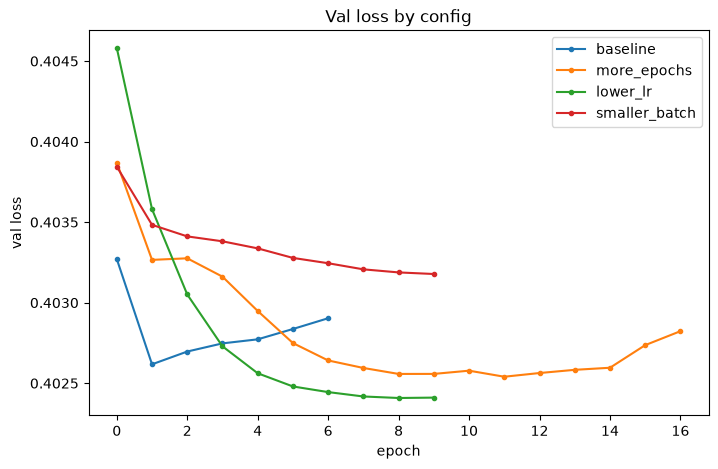

In [31]:
plt.figure(figsize=(8, 5))
for r in sweep_results:
    plt.plot(r["val_losses"], label=r["name"], marker="o", markersize=3)
plt.xlabel("epoch")
plt.ylabel("val loss")
plt.title("Val loss by config")
plt.legend()
plt.show()